# Project 2 — NLP | Step 3: Results Interpretations

**Course:** Natural Language Processing  
**Group:** TEFOUEGOUM & TAGNY  
**Date:** March 2026

---

## Objectives
In this step, we analyze the results obtained from the topic modeling process.
The objective is to understand and interpret the topics discovered in the previous step,
and to explore how these topics relate to customer opinions and behaviors.

Each review in the dataset has been assigned to a dominant topic,
which represents the main theme discussed in that review.
By studying the distribution and characteristics of these topics,
we can identify the most frequent concerns and recurring issues among customers.

This analysis focuses on several key aspects:

- The distribution of topics across the dataset
- The most important keywords associated with each topic
- The relationship between topics and sentiment (positive, neutral, negative)
- The relationship between topics and ratings (customer satisfaction)
- The distribution of topics across different insurers

These insights allow us to better understand customer feedback
and identify strengths and weaknesses in insurance services.

The results of this step provide valuable input for the next stages of the project,
including supervised learning and the development of interactive applications.

**Input:** `insurance_reviews_topics.csv` produced in Step 2  
**Output:** visualizations and interpretations of topics and their impact on sentiment and ratings

---

In [ ]:
import importlib, subprocess, sys

required = {
    'pandas'   : 'pandas',
    'numpy'    : 'numpy',
    'matplotlib': 'matplotlib',
    'sklearn'  : 'scikit-learn',
    'gensim'   : 'gensim',
    'pyLDAvis' : 'pyldavis',
    'nltk'     : 'nltk',
    'transformers' : 'transformers'
}

for import_name, install_name in required.items():
    try:
        importlib.import_module(import_name)
        print(f'  OK      {import_name}')
    except ImportError:
        print(f'  MISSING {import_name} -- installing...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', install_name, '-q'])
        print(f'  DONE    {import_name}')

print('\nAll packages available. Restart the kernel if anything was just installed, then run Section 1.')

  OK      pandas
  OK      numpy
  OK      matplotlib
  OK      sklearn
  OK      gensim


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  OK      pyLDAvis


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  OK      nltk


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  OK      transformers

All packages available. Restart the kernel if anything was just installed, then run Section 1.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 1 - Import Libraries

In [ ]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm.auto import tqdm
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM

# Sklearn — NMF and vectorization
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF

# Gensim — LDA
import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# pyLDAvis — interactive visualization
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries loaded:')
print(f'  gensim    {gensim.__version__}')
print(f'  pyLDAvis  {pyLDAvis.__version__}')
print(f'  sklearn   imported')
print(f'  pandas    {pd.__version__}')

Libraries loaded:
  gensim    4.4.0
  pyLDAvis  3.4.0
  sklearn   imported
  pandas    2.2.2


---
## 2 - Loading the Topic Dataset

In [ ]:
CSV_PATH = r'Traduction avis clients/insurance_reviews_topics.csv'

df = pd.read_csv(CSV_PATH)

print(f'Shape          : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns        : {list(df.columns)}')
print(f'Missing text_clean : {df["text_clean"].isna().sum()}')
print()
print(df.head(3))

Shape          : 24,065 rows x 16 columns
Columns        : ['note', 'sentiment', 'auteur', 'assureur', 'produit', 'type', 'avis', 'avis_en', 'avis_spell_corrected', 'text_clean', 'tokens', 'lda_topic_id', 'lda_topic_prob', 'lda_topic_label', 'nmf_topic_id', 'nmf_topic_label']
Missing text_clean : 0

   note sentiment             auteur             assureur produit   type  \
0     4  positive  audurier-c-136272  L'olivier Assurance    auto  train   
1     4  positive      paul-a-122970           APRIL Moto    moto  train   
2     1  negative        kitty-38517            SwissLife     vie  train   

                                                avis  \
0  La personne au téléphone était Clair et sympat...   
1  Satisfait.\n\nRéactivité, simplicité. Prix att...   
2  Assureur à fuir, n assure pas ses responsabili...   

                                             avis_en  \
0  The person on the phone was clear and friendly...   
1  Satisfied.\n\nReactivity, simplicity. Attracti...   
2

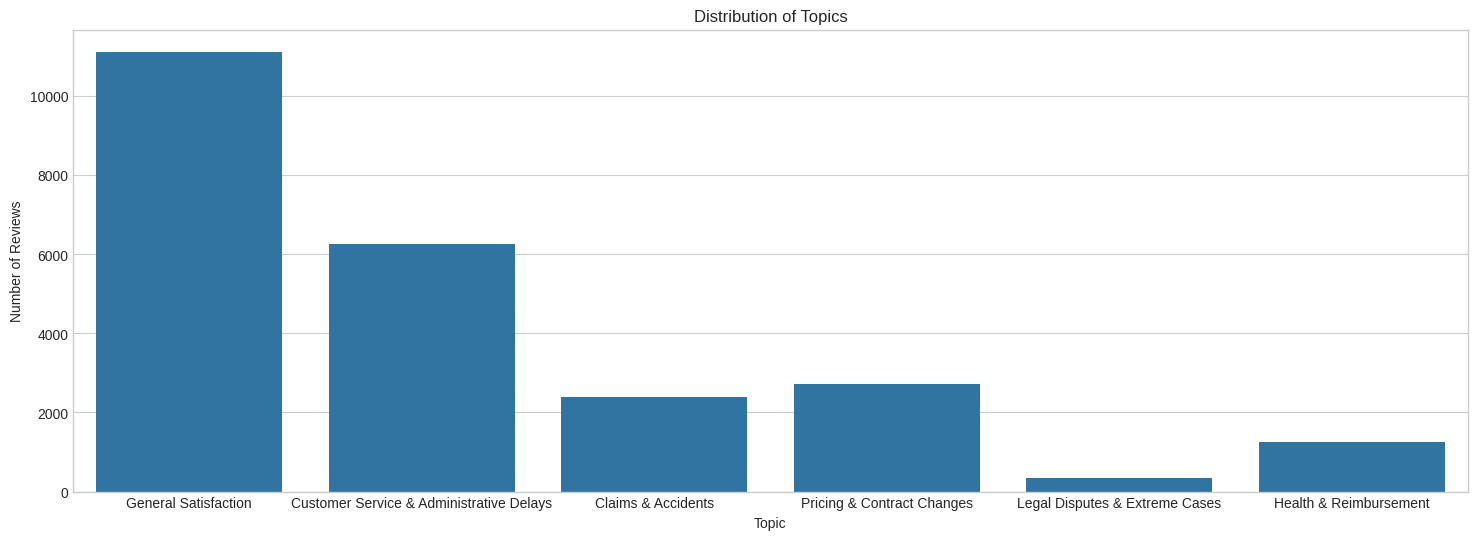

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(18,6))
sns.countplot(x='lda_topic_label', data=df)
plt.title("Distribution of Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Reviews")
plt.show()
plt.savefig('Traduction avis clients/Traduction avis clients graphiques/ 09_lda_topic_distribution.png', dpi=150)

We use LDA topics as the main reference for analysis, as they provide a probabilistic interpretation of topic distribution. NMF topics are used as a complementary approach for comparison.

- The theme “General Satisfaction” is by far the most common, indicating that a large number of reviews express general opinions rather than focusing on specific issues. This means that customers often share their overall impressions of their experiences.

- In second, the most common topic is “Customer Service and Administrative Delays,” highlighting that operational inefficiencies and service quality are major concerns for customers. This suggests that improving customer service could significantly boost user satisfaction.

- Intermediate topics such as “Pricing and Contract Changes” and “Claims and Accidents” are also well-represented. These topics reflect key aspects of the insurance experience, particularly regarding costs and claims management.

- On the contrary, themes such as “Health and Reimbursement” and “Legal Disputes and Extreme Cases” are less frequent. These likely correspond to more specific or exceptional situations, which occur less frequently but can nonetheless represent critical issues.

Overall, this distribution shows that while general satisfaction dominates customer feedback, operational and service-related issues remain central concerns that insurers must address.

---
## 3 - KeyWords by topic

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_words_by_topic(df, topic_col, text_col, n_words=10):
    topics = sorted(df[topic_col].dropna().unique())

    for t in topics:
        # Filter posts in this thread
        text_data = df[df[topic_col] == t][text_col].dropna()

        # Security in case of it's empty
        if len(text_data) == 0:
            continue

        # Vectorization
        vectorizer = CountVectorizer(stop_words='english')
        X = vectorizer.fit_transform(text_data.astype(str))

        words = vectorizer.get_feature_names_out()
        counts = X.sum(axis=0).A1

        # Sort the words
        word_freq = sorted(zip(words, counts), key=lambda x: x[1], reverse=True)

        print(f"\n Topic: {t}")
        print([w for w, _ in word_freq[:n_words]])

get_top_words_by_topic(df, "lda_topic_label", "text_clean")


 Topic: Claims & Accidents
['vehicle', 'expert', 'car', 'accident', 'maif', 'responsible', 'disaster', 'damage', 'following', 'pay']

 Topic: Customer Service & Administrative Delays
['contract', 'service', 'months', 'file', 'phone', 'customer', 'time', 'email', 'sent', 'answer']

 Topic: General Satisfaction
['satisfied', 'service', 'price', 'prices', 'good', 'recommend', 'thank', 'fast', 'simple', 'customer']

 Topic: Health & Reimbursement
['mutual', 'care', 'pay', 'flee', 'health', 'months', 'reimbursed', 'contract', 'euros', 'reimbursements']

 Topic: Legal Disputes & Extreme Cases
['axa', 'life', 'flee', 'contract', 'money', 'make', 'bad', 'company', 'service', 'capital']

 Topic: Pricing & Contract Changes
['contract', 'price', 'increase', 'euros', 'car', 'home', 'vehicle', 'bonus', 'insured', 'customer']


To better understand the meaning of each topic, we extract the most frequent words associated with each topic.

This allows us to interpret the themes identified by the topic modeling algorithms and assign meaningful labels such as pricing, customer service, or claims processing.

The most frequent words provide insight into the key issues discussed within each topic.

<br>


Analyzing the most frequent words for each theme allows us to identify the main themes present in the dataset.

The “Claims and Accidents” theme pertains to accident management, including vehicle damage, damage assessments, and liability. It reflects customers' experiences with claims processing.

The “Customer Service and Administrative Delays” theme highlights issues related to communication and processing times, with frequent mentions of phone calls, emails, and delays in responses. This suggests that customer service is a major area of concern.

The “Overall Satisfaction” theme contains positive terms such as “satisfied,” “good,” and “recommend,” indicating generally positive feedback and an overall satisfactory customer experience.

The “Health and Reimbursement” theme focuses on medical coverage and reimbursement processes, often associated with payment delays and administrative procedures.

The “Legal Disputes and Extreme Cases” theme includes words related to conflicts, financial problems, and dissatisfaction. Although less frequent, these cases represent serious negative experiences.

The “Pricing and Contract Changes” section addresses concerns regarding insurance costs, price increases, and contract terms, which are key factors influencing customer satisfaction.

---
## 4 - Topic vs Sentiment

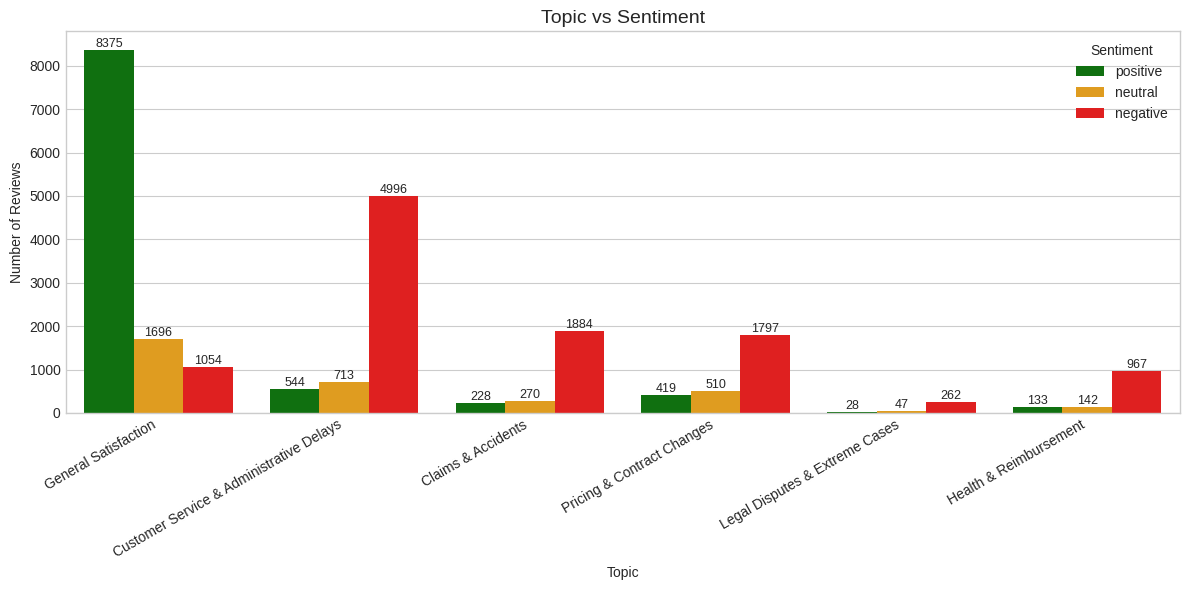

<Figure size 640x480 with 0 Axes>

In [ ]:
order = ["positive", "neutral", "negative"]

colors = {"positive": "green",
          "neutral": "orange",
          "negative": "red"}

plt.figure(figsize=(12,6))

ax = sns.countplot( x='lda_topic_label', hue='sentiment', data=df, hue_order=order, palette=colors)

# Value by bar in the barplot
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom', fontsize=9)
plt.title("Topic vs Sentiment", fontsize=14)
plt.xlabel("Topic")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=30, ha='right') #libibility of the titles

plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()
plt.savefig('Traduction avis clients/Traduction avis clients graphiques/10_topic_by_sentiments.png', dpi=150)

The "General Satisfaction" topic is largely dominated by positive reviews, indicating that customers often express overall satisfaction with their experience.

In contrast, several topics are strongly associated with negative sentiment :

The "Customer Service & Administrative Delays" topic shows a very high number of negative reviews, highlighting major issues related to communication and processing times. This suggests that customer support is a critical weakness.

Similarly, topics such as "Claims & Accidents", "Pricing & Contract Changes", and "Health & Reimbursement" are predominantly negative. These areas correspond to key aspects of the insurance experience, including claim handling, pricing policies, and reimbursement processes.

The "Legal Disputes & Extreme Cases" topic, although less frequent, is also highly negative, indicating serious dissatisfaction in specific situations.

Overall, the results show that positive feedback is mostly general, while negative feedback is concentrated on specific operational issues.

---
## 5 - Topic vs Note

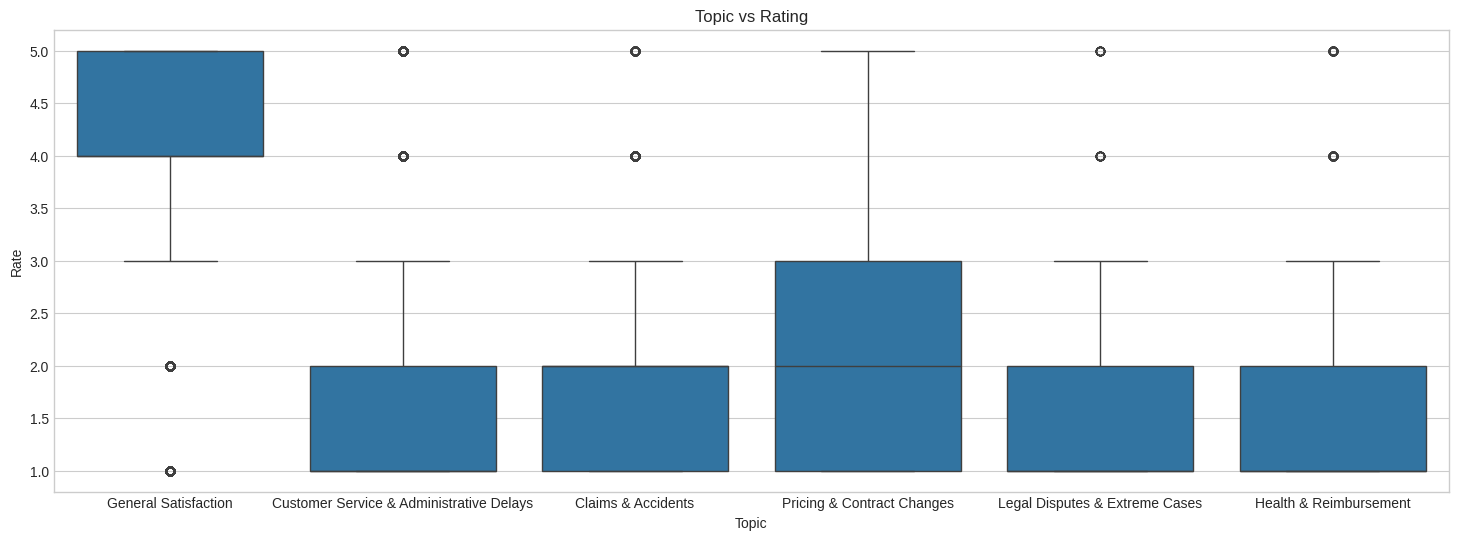

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(18,6))
sns.boxplot(x='lda_topic_label', y='note', data=df)
plt.title("Topic vs Rating")
plt.xlabel("Topic")
plt.ylabel("Rate")
plt.show()
plt.savefig('Traduction avis clients/Traduction avis clients graphiques/11_topic_vs_rating.png', dpi=150)

As we saw before, the "General Satisfaction" topic shows high ratings, with a median around 4, indicating that this category corresponds to overall positive experiences.

In contrast, "Customer Service & Administrative Delays", "Claims & Accidents", "Health & Reimbursement", and "Legal Disputes & Extreme Cases" are associated with low ratings, typically between 1 and 2. This indicates strong dissatisfaction in these areas.

The "Pricing & Contract Changes" topic presents a more mixed distribution, with a wider spread of ratings. This suggests that pricing issues generate both positive and negative reactions depending on the situation.

Finally, the results confirm that while general feedback is positive, specific operational aspects such as customer service, claims management, and reimbursements are major sources of dissatisfaction.

---
## 6 - Topic vs Insurer

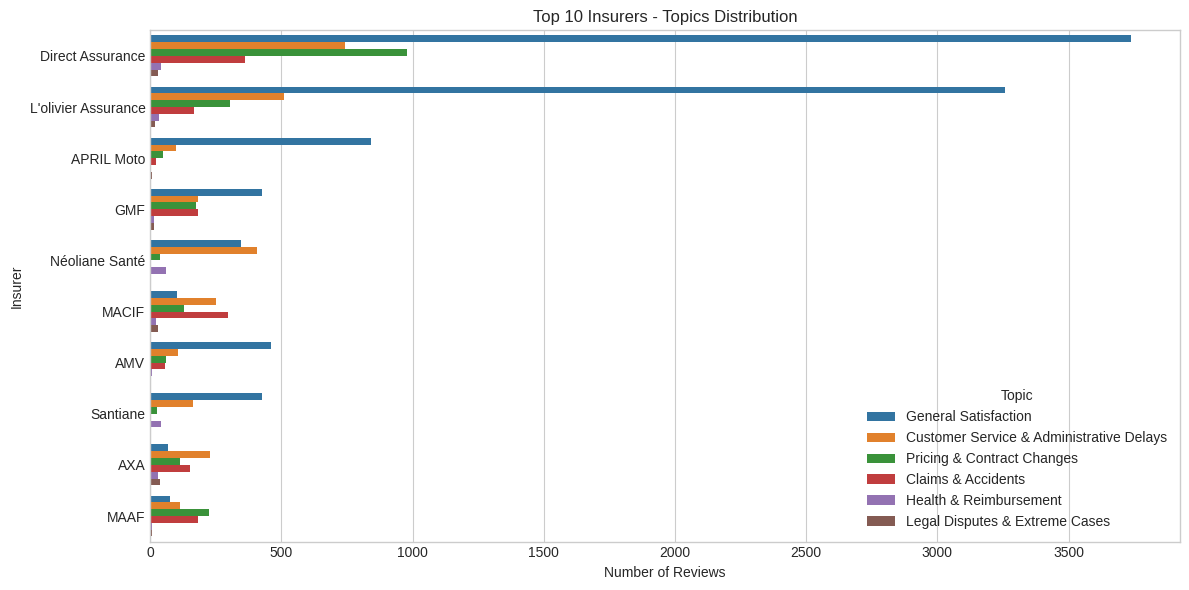

<Figure size 640x480 with 0 Axes>

In [ ]:
top_10 = df['assureur'].value_counts().head(10).index

df_top10 = df[df['assureur'].isin(top_10)]

plt.figure(figsize=(12,6))
sns.countplot(y='assureur', hue='lda_topic_label', data=df_top10, order=top_10)
plt.title("Top 10 Insurers - Topics Distribution")
plt.xlabel("Number of Reviews")
plt.ylabel("Insurer")

plt.legend(title="Topic")

plt.tight_layout()
plt.show()
plt.savefig('Traduction avis clients/Traduction avis clients graphiques/12_TOP_Insurer_by_topic.png', dpi=150)

General Satisfaction clearly dominates across all companies, indicating that many reviews express overall opinions rather than focusing on specific issues.

At the same time, several recurring topics appear across all insurers, particularly Customer Service & Administrative Delays, Pricing & Contract Changes, and Claims & Accidents. These themes are consistently present regardless of the company.

This suggests that customer concerns are not isolated to a single insurer but are shared across the entire industry.

The satisfaction tends to be expressed in general terms, while dissatisfaction is linked to specific operational issues such as customer service, pricing, and claims management.

---
## Auto-summarization (BART/T5)

In [ ]:
df_sum = df.copy()

# Choix intelligent du texte
if "avis_spell_corrected" in df_sum.columns:
    text_col = "avis_spell_corrected"
elif "avis_en" in df_sum.columns:
    text_col = "avis_en"
else:
    text_col = "text_clean"

df_sum = df_sum[["assureur", text_col, "note", "sentiment", "lda_topic_label"]].dropna()

df_sum[text_col] = df_sum[text_col].astype(str).str.strip()
df_sum = df_sum[df_sum[text_col] != ""]

In [ ]:
summarizer = pipeline("text-generation", model="t5-small", tokenizer="t5-small")

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'ExaoneMoeForCausalLM', 'FalconForCausalLM', 'FalconH1ForCausalL

In [ ]:
def split_text(text, max_words=120):
    words = text.split()
    return [" ".join(words[i:i+max_words]) for i in range(0, len(words), max_words)]


def summarize_text_safe(text, max_chunks=5):
    chunks = split_text(text)

    # Limit to 30 min
    chunks = chunks[:max_chunks]

    summaries = []

    for chunk in chunks:
        try:
            summary = summarizer("summarize: " + chunk, max_length=60, min_length=20, do_sample=False )[0]["summary_text"]
        except:
            summary = chunk[:150]
        summaries.append(summary)

    return " ".join(summaries)

In [ ]:
#Group by insurers
insurer_groups = ( df_sum.groupby("assureur").agg(
        review_count=(text_col, "count"),
        avg_rating=("note", "mean"),
        dominant_sentiment=("sentiment", lambda x: x.mode()[0]),
        dominant_topic=("lda_topic_label", lambda x: x.mode()[0]),
        all_reviews=(text_col, lambda x: " ".join(x.tolist()))
    ).reset_index())

In [ ]:
tqdm.pandas()

insurer_groups["summary"] = insurer_groups["all_reviews"].progress_apply(lambda x: summarize_text_safe(x))

  0%|          | 0/56 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'min_length', 'do_sample', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will 

In [ ]:
insurer_summary = insurer_groups[["assureur", "review_count", "avg_rating", "dominant_sentiment", "dominant_topic", "summary"]]
insurer_summary.to_csv("Traduction avis clients/insurance_insurer_summaries.csv", index=False)

File save: insurance_insurer_summaries.csv


In [ ]:
for _, row in insurer_summary.head(10).iterrows():
    print("Insurer:", row["assureur"])
    print("Reviews:", row["review_count"])
    print("Avg rating:", round(row["avg_rating"], 2))
    print("Sentiment:", row["dominant_sentiment"])
    print("Topic:", row["dominant_topic"])
    print("Summary:", row["summary"])

Insurer: AMV
Reviews: 688
Avg rating: 3.69
Sentiment: positive
Topic: General Satisfaction
Summary: Competitive price, reactive customer service and high -performance web interface. I have been a customer for 5 years and I highly recommend. I recentl you pay 150 € of insurance and you ask you to take the lead to make a postal transfer which costs 20 €. We swim in delirium! By behaving thus, AMV enc the possibility of getting a new vehicle with the old one. A lot of blur Thank you for the simplicity of using your website and your competitive price the first 3 months, all the documents send but no green card despite the threads to the customer services and "do not worry this is being treatment .. for an à la carte contract, with a price corresponding to my expectations Do not forget that insurance is compulsory. Therefore we have no choice. But
Insurer: APRIL
Reviews: 283
Avg rating: 2.42
Sentiment: negative
Topic: Customer Service & Administrative Delays
Summary: I took health insurance

The summarization results show that the T5 model is able to capture the main ideas expressed in customer reviews at the insurer level.

The generated summaries are consistent with both sentiment and rating distributions, highlighting key issues such as customer service delays, contract management problems, and pricing concerns.

This step provides a more interpretable and business-oriented view of customer feedback compared to topic modeling alone.

However, some limitations are observed, including slight incoherence in long summaries due to chunking and occasional redundancy.

To improve the model's performance and ensure it can understand all elements of the reviews, you should use a model that incorporates “self-attention” or “cross-attention.”